In [1]:
import pandas as pd

#taking chunks of data instead of all at once to evade memory problems
chunk_size = 50000  
chunks = []

for filename in ["C:\\Users\\Furkan\\Desktop\\complete_measure_node_airport_brown.csv", 
                 "C:\\Users\\Furkan\\Desktop\\complete_measure_node_airport_silver.csv", 
                 "C:\\Users\\Furkan\\Desktop\\complete_measure_node_airport_gold.csv"]:
    chunk_iter = pd.read_csv(filename, delimiter=';', chunksize=chunk_size)
    for chunk in chunk_iter:
        chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)

In [2]:
#turning null values into 0s
columns_to_fill = [
    'sps30_pm05_count', 'sps30_pm1_count', 'sps30_pm25_count', 'sps30_pm4_count',
    'sps30_pm10_count', 'sps30_pm_typ', 'sps30_pm25_ug', 'sps30_pm4_ug', 'sps30_pm10_ug'
]

df[columns_to_fill] = df[columns_to_fill].fillna(0)

print(df.isnull().sum())

id_measure          0
node_id             0
ads1115_value       0
ads1115_voltage     0
scd30_co2           0
scd30_temp          0
scd30_hum           0
sps30_pm05_count    0
sps30_pm1_count     0
sps30_pm1_ug        1
sps30_pm25_count    0
sps30_pm25_ug       0
sps30_pm4_count     0
sps30_pm4_ug        0
sps30_pm10_count    0
sps30_pm10_ug       0
sps30_pm_typ        0
ts_insertion        0
dtype: int64


In [3]:
df['brown'] = (df['node_id'] == 'node-air-brown').astype(int)
df['gold'] = (df['node_id'] == 'node-air-gold').astype(int)
df['silver'] = (df['node_id'] == 'node-air-silver').astype(int)

df = df.drop(columns=['id_measure'])
df = df.drop(columns=['node_id'])

df['ts_insertion'] = pd.to_datetime(df['ts_insertion'])

int_cols = df.select_dtypes(include=['int64']).columns
df[int_cols] = df[int_cols].astype('float64')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28177936 entries, 0 to 28177935
Data columns (total 19 columns):
 #   Column            Dtype         
---  ------            -----         
 0   ads1115_value     float64       
 1   ads1115_voltage   float64       
 2   scd30_co2         float64       
 3   scd30_temp        float64       
 4   scd30_hum         float64       
 5   sps30_pm05_count  float64       
 6   sps30_pm1_count   float64       
 7   sps30_pm1_ug      float64       
 8   sps30_pm25_count  float64       
 9   sps30_pm25_ug     float64       
 10  sps30_pm4_count   float64       
 11  sps30_pm4_ug      float64       
 12  sps30_pm10_count  float64       
 13  sps30_pm10_ug     float64       
 14  sps30_pm_typ      float64       
 15  ts_insertion      datetime64[ns]
 16  brown             float64       
 17  gold              float64       
 18  silver            float64       
dtypes: datetime64[ns](1), float64(18)
memory usage: 4.0 GB


In [4]:
def handle_outliers_iqr(data, columns):
    data_cleaned = data.copy()
    for col in columns:
        Q1 = data_cleaned[col].quantile(0.25)  
        Q3 = data_cleaned[col].quantile(0.75)  
        IQR = Q3 - Q1  
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        data_cleaned[col] = data_cleaned[col].clip(lower=lower_bound, upper=upper_bound)
    return data_cleaned

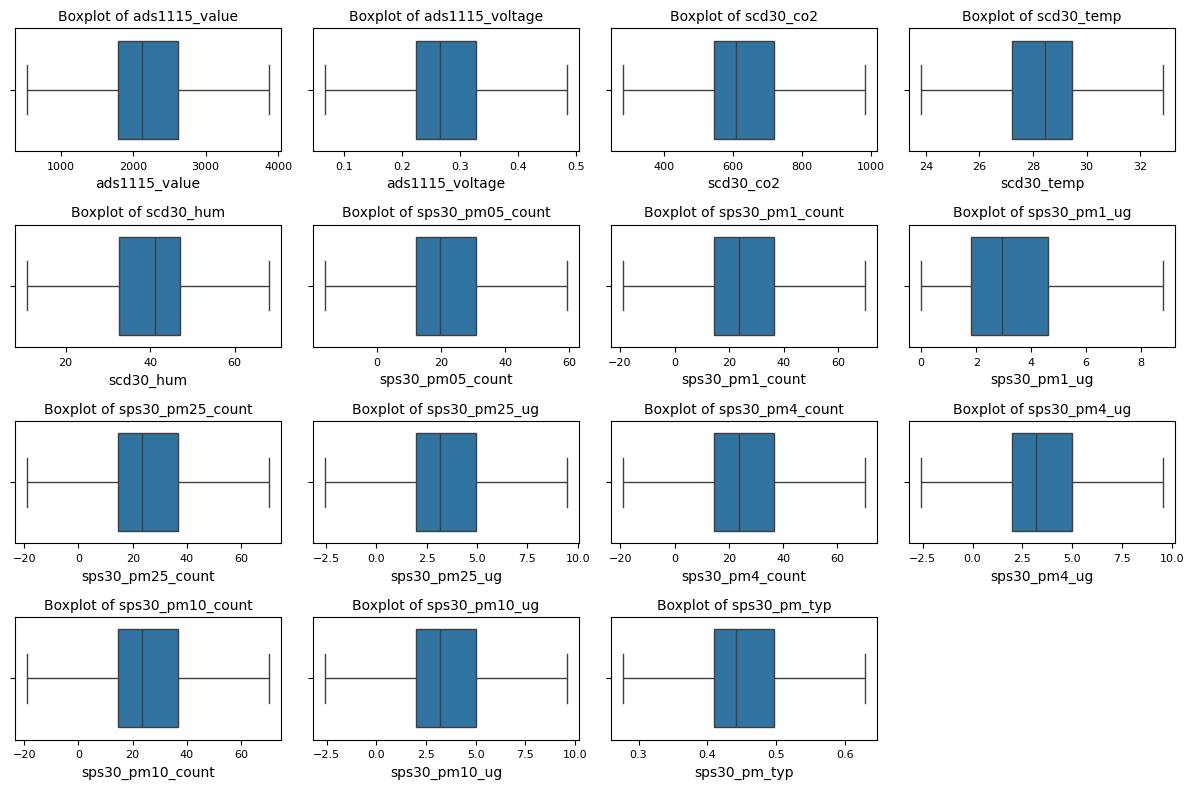

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns 
cleaned_data = handle_outliers_iqr(df, numeric_cols)

numeric_cols = [col for col in numeric_cols if col not in ['brown', 'silver', 'gold']]

plt.figure(figsize=(12, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(data=cleaned_data, x=col)
    plt.title(f"Boxplot of {col}", fontsize=10)
    plt.xticks(fontsize=8)  

plt.subplots_adjust(hspace=0.6, wspace=0.4) #spacing each plot so they don't collide with one anohter

plt.tight_layout()
plt.show()

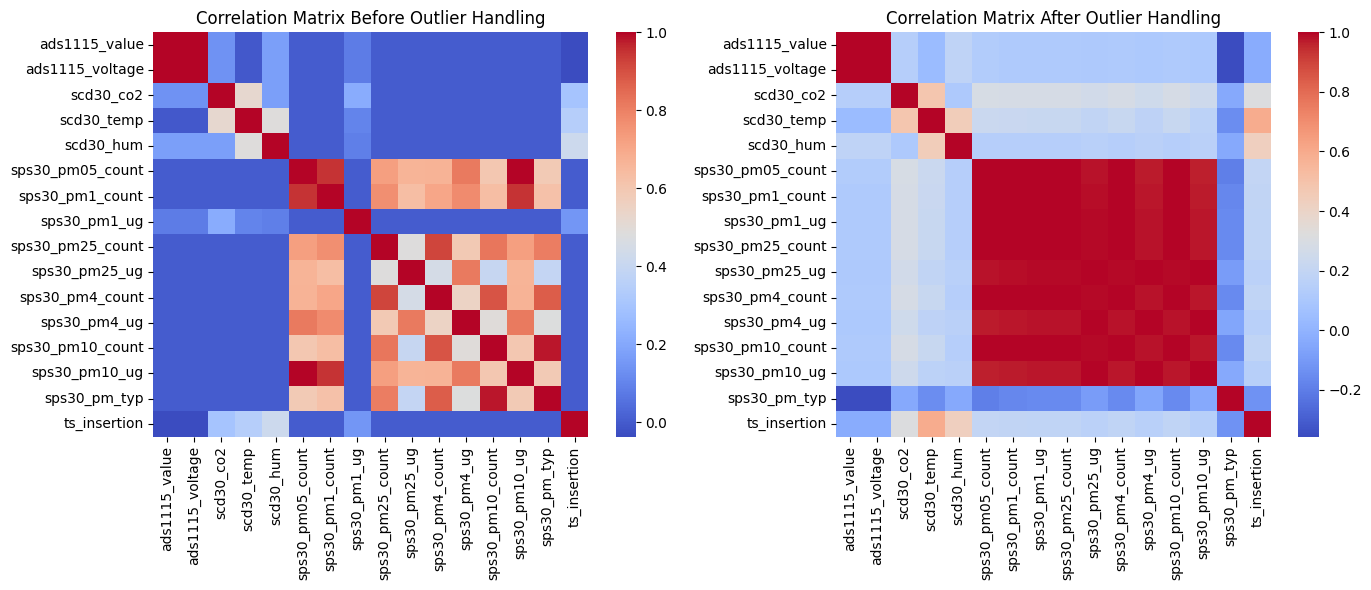

In [6]:
columns_to_exclude = ['brown', 'silver', 'gold']
filtered_original = df.drop(columns=columns_to_exclude, errors='ignore')
filtered_cleaned = cleaned_data.drop(columns=columns_to_exclude, errors='ignore')

correlation_original = filtered_original.corr()
correlation_cleaned = filtered_cleaned.corr()

plt.figure(figsize=(14, 6))

#Original data correlation matrix
plt.subplot(1, 2, 1)
sns.heatmap(correlation_original, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix Before Outlier Handling')

#Cleaned data correlation matrix
plt.subplot(1, 2, 2)
sns.heatmap(correlation_cleaned, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix After Outlier Handling')

plt.tight_layout()
plt.show()

In [13]:
#Stratified sampling
brown_sample = df[df['brown'] == 1].groupby('sps30_pm_typ', group_keys=False).apply(lambda x: x.sample(frac=0.1))
gold_sample = df[df['gold'] == 1].groupby('sps30_pm_typ', group_keys=False).apply(lambda x: x.sample(frac=0.1))
silver_sample = df[df['silver'] == 1].groupby('sps30_pm_typ', group_keys=False).apply(lambda x: x.sample(frac=0.1))

print("Brown Sample CO2 Mean:", brown_sample['scd30_co2'].mean())
print("Gold Sample CO2 Mean:", gold_sample['scd30_co2'].mean())
print("Silver Sample CO2 Mean:", silver_sample['scd30_co2'].mean())

C:\Users\Furkan\AppData\Local\Temp\ipykernel_16988\1793048971.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  brown_sample = df[df['brown'] == 1].groupby('sps30_pm_typ', group_keys=False).apply(lambda x: x.sample(frac=0.1))
C:\Users\Furkan\AppData\Local\Temp\ipykernel_16988\1793048971.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gold_sample = df[df['gold'] == 1].groupby('sps30_pm_typ', group_keys

Brown Sample CO2 Mean: 660.9622185450919
Gold Sample CO2 Mean: 660.0839188085181
Silver Sample CO2 Mean: 637.2300334685523


C:\Users\Furkan\AppData\Local\Temp\ipykernel_16988\1793048971.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  silver_sample = df[df['silver'] == 1].groupby('sps30_pm_typ', group_keys=False).apply(lambda x: x.sample(frac=0.1))


In [14]:
import numpy as np
import pandas as pd

#Cluster sampling
def cluster_sampling(df, number_of_clusters):
    try:
        cluster_size = len(df) // number_of_clusters
        remaining = len(df) % number_of_clusters
        cluster_ids = np.repeat(range(1, number_of_clusters + 1), cluster_size)         #creating the cluster_id column
        cluster_ids = np.concatenate([cluster_ids, np.repeat(range(1, remaining + 1), 1)])
        
        np.random.shuffle(cluster_ids)
        df['cluster_id'] = cluster_ids
        
        indexes = df[df['cluster_id'] % 2 == 0].index
        
        cluster_sample = df.loc[indexes]
        return cluster_sample
    except Exception as e:
        print(f"An error occurred: {e}")
        return pd.DataFrame()  
        
cluster_sample = cluster_sampling(df, 5)

if cluster_sample.empty:
    print("No valid cluster sample was created.")
else:
    print("Cluster Sample CO2 Mean:", cluster_sample['scd30_co2'].mean())

Cluster Sample CO2 Mean: 647.0638533336452


In [16]:
from scipy.stats import f_oneway

brown_group = df[df['brown'] == 1]['scd30_co2']
gold_group = df[df['gold'] == 1]['scd30_co2']
silver_group = df[df['silver'] == 1]['scd30_co2']

#ANOVA
f_stat, p_value = f_oneway(brown_group, gold_group, silver_group)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("There is a statistically significant difference between the groups.")
else:
    print("There is no statistically significant difference between the groups.")

F-Statistic: 80501.23348505184
P-Value: 0.0
There is a statistically significant difference between the groups.


In [17]:
from random import sample

co2_list = list(df[df['gold'] == 1]['scd30_co2'])

#simple random sampling (500 samples)
sample_co2 = sample(co2_list, 500)

print("Simple Random Sample CO2 Mean:", sum(sample_co2) / len(sample_co2))

Simple Random Sample CO2 Mean: 663.1795
